# Find all survey intersections

This notebooks demonstrates the `network` method of finding crossovers or intersections between all the flights or lines of a survey. See the past notebooks for more details on the specifics of finding crossovers.

In [37]:
%load_ext autoreload
%autoreload 2


import logging

import matplotlib.pyplot as plt
import pandas as pd
import plotly.io as pio

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()
pio.renderers.default = "notebook"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data

This is a subset of the PolarGAP survey over Antarctica's south pole. The file is downloaded and processed in the notebook `PolarGAP_magnetic_survey`.

In [ ]:
data_df = pd.read_csv("data/PolarGAP_magnetic_survey.csv")

data_df = data_df.drop(columns="line")

data_df = data_df[
    [
        "easting",
        "northing",
        "Elev",
        "distance_along_flight",
        "unixtime",
        "flight",
    ]
]

data_df = data_df.sort_values(["flight", "unixtime"])
data_df = data_df.dropna(how="any")

# only use every 5th point to speed up the notebook
data_df = data_df[::5]

# for testing, only use some flights
data_df = data_df[~data_df.flight.isin([1, 5, 8])]
data_df = data_df[
    data_df.flight.isin(data_df.flight.unique()[data_df.flight.unique() % 2 == 0])
]

# rename flights sequentially from 1
survey = airbornegeo.Survey(data_df, line_column="flight", copy=False)
survey.unique_line_id()

data_df.head()

This subset of the survey has 17 flights, which can't be categorized into groups due to the unconventional survey design. This means we can't use the `groups` method to define crossovers, but need the `network` method.You can see the flight names using the  `unique()` method of pandas. We plot the data below and label each flight with it's name.

In [39]:
data_df.flight.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

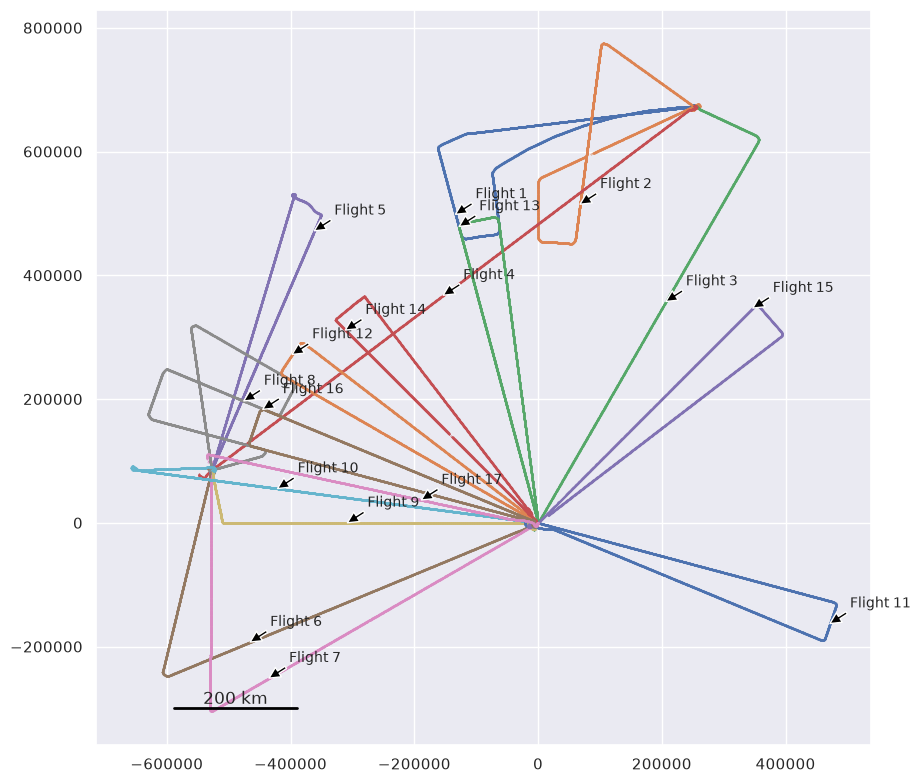

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))
for name, line_data in data_df.groupby("flight"):
    # plot points
    ax.scatter(
        line_data.easting,
        line_data.northing,
        s=0.1,
    )
    # location for label
    label_point = line_data.iloc[len(line_data) // 2]
    ax.annotate(
        f"Flight {name}",
        xy=(label_point.easting, label_point.northing),
        xycoords="data",
        xytext=(20, 20),
        textcoords="offset pixels",
        fontsize=10,
        arrowprops={
            "facecolor": "black",
            "headwidth": 8,
            "headlength": 8,
            "width": 2,
        },
        ha="left",
        va="center",
    )
ax.set_aspect("equal")
airbornegeo.add_scalebar(ax, 200e3)

## Calculate intersections between all flights
We want to calculate the theoretical intersection points between all combinations of flights. 

In [ ]:
# calculate theoretical intersection points
survey.create_intersection_table(method="network")
inters = survey.intersections
inters

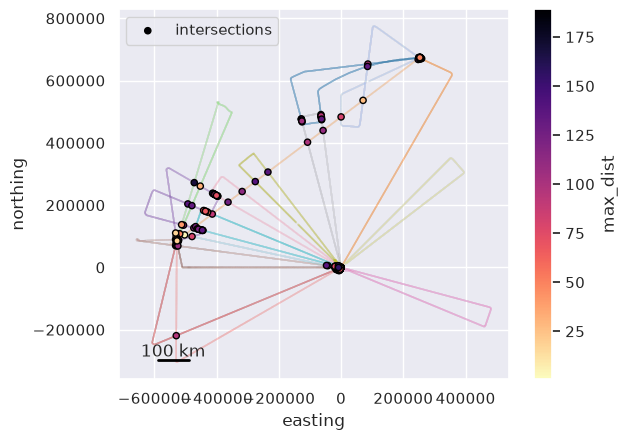

In [42]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="flight",
    s=0.001,
    marker=".",
    cmap="tab20",
    colorbar=False,
)
inters.plot.scatter(
    "easting",
    "northing",
    c="max_dist",
    s=20,
    cmap="magma_r",
    marker="o",
    edgecolor="black",
    ax=ax,
    label="intersections",
)
airbornegeo.add_scalebar(ax, 100e3)
ax.set_aspect("equal")

We can analyze the `max_dist` values to see if there are any outlier crossovers which are really far from the nearest data.

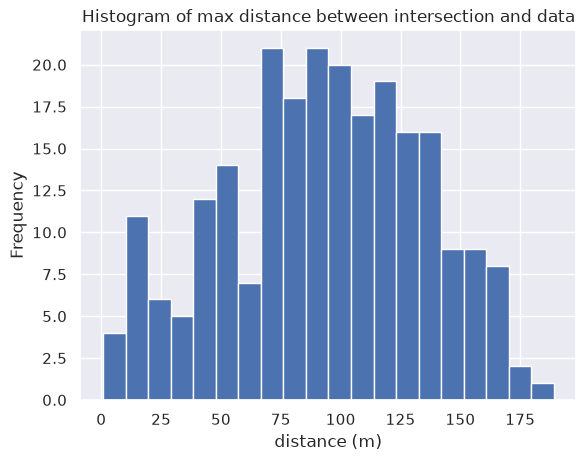

In [43]:
ax = inters.max_dist.plot.hist(bins=20)
ax.set_xlabel("distance (m)")
ax.set_title("Histogram of max distance between intersection and data");

In [ ]:
# We can see which lines don't have any intersections.
airbornegeo.lines_without_intersections(survey.data, survey.intersections)

## Including proximal intersections

In the "Find crossover points" notebook we showed how you can extend the ends of line to include crossover points which are just off the end of a line using the parameter `buffer_dist`. This extends line along their direction. If two lines are subparallel, but very close to each other, we may want to include the point where they are closest to each other as an intersection, but since they are sub-parallel, ending them along their directions may not result in an intersection. 

For this we can use the parameter `proximity_dist` which will count any points between two lines which are closer than this distance as an intersection. The intersection point will be placed at the midpoint between the two lines. 

If long sections of the lines are close together, this will make many new intersections points. You can you `block_size` to only retain 1 intersection per each spatial block of specified width. 

To demonstrate this, we will find the intersections for 2 subparallel lines.

In [ ]:
data_df = pd.read_csv("data/PolarGAP_magnetic_survey.csv")

data_df = data_df.drop(columns="line")

data_df = data_df[
    [
        "easting",
        "northing",
        "unixtime",
        "flight",
    ]
]

data_df = data_df.sort_values(["flight", "unixtime"])
data_df = data_df.dropna(how="any")

data_df = data_df[data_df.flight.isin([32, 7])]
data_df = data_df[data_df.easting > 0]

# Create a new survey for this demonstration section
survey = airbornegeo.Survey(data_df, line_column="flight", copy=False)

Below you can see no intersections are found, even when the lines are buffered by 250 m. This is shown on the left subplot below.

In [ ]:
survey.create_intersection_table(
    method="network",
    buffer_dist=250,  # extend each line 250 m along the direction of the line
)
buffer_inters = survey.intersections
buffer_inters

Below you can see now that an intersection is found if the look for any points within 250 m of each other. This is shown on the right subplot below.

In [ ]:
# calculate theoretical intersection points
survey.create_intersection_table(
    method="network",
    proximity_dist=250,  # count any datapoints within 250 m of each as intersections
    block_size=500,  # only retain 1 intersection per pair of lines within any 500 m window
)
proximity_inters = survey.intersections
proximity_inters

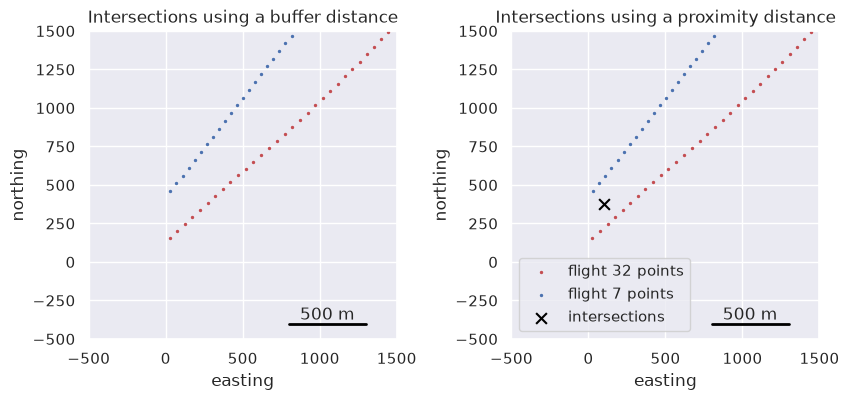

In [52]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

reg = (-500, 1.5e3, -500, 1.5e3)

ax = axs[0]
ax = data_df[data_df.flight == 32].plot.scatter(
    "easting",
    "northing",
    color="r",
    s=2,
    ax=ax,
)
ax = data_df[data_df.flight == 7].plot.scatter(
    "easting",
    "northing",
    color="b",
    s=2,
    ax=ax,
)
ax.set_title("Intersections using a buffer distance")
ax.set_xlim(reg[0], reg[1])
ax.set_ylim(reg[2], reg[3])
ax.set_aspect("equal")
airbornegeo.add_scalebar(ax, 500, "bottom right")


ax = axs[1]
ax = data_df[data_df.flight == 32].plot.scatter(
    "easting",
    "northing",
    color="r",
    s=2,
    label="flight 32 points",
    ax=ax,
)
ax = data_df[data_df.flight == 7].plot.scatter(
    "easting",
    "northing",
    color="b",
    s=2,
    ax=ax,
    label="flight 7 points",
)
proximity_inters.plot.scatter(
    "easting",
    "northing",
    color="black",
    s=60,
    marker="x",
    ax=ax,
    label="intersections",
)
ax.set_title("Intersections using a proximity distance")
ax.legend(loc="lower left")
ax.set_xlim(reg[0], reg[1])
ax.set_ylim(reg[2], reg[3])
ax.set_aspect("equal")
airbornegeo.add_scalebar(ax, 500, "bottom right")